In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from glob import glob

sar_path = '/content/drive/MyDrive/barrenland/s1'
rgb_path = '/content/drive/MyDrive/barrenland/s2'

sar_images = sorted(glob(os.path.join(sar_path, '*.png')))
rgb_images = sorted(glob(os.path.join(rgb_path, '*.png')))

print(f'Total SAR images: {len(sar_images)}')
print(f'Total RGB images: {len(rgb_images)}')

Total SAR images: 4000
Total RGB images: 4000


In [ ]:
!pip install scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import tensorflow as tf


In [6]:
import cv2
import numpy as np
from tqdm import tqdm  # progress bar

IMG_SIZE = 128

def preprocess(index):
    sar = cv2.imread(sar_images[index], cv2.IMREAD_GRAYSCALE)
    rgb = cv2.imread(rgb_images[index])  # BGR format

    if sar is None or rgb is None:
        print(f"❌ Skipping index {index} - image not loaded properly.")
        return None, None

    sar = cv2.resize(sar, (IMG_SIZE, IMG_SIZE))
    rgb = cv2.resize(cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))

    sar = sar.astype('float32') / 255.0
    rgb = rgb.astype('float32') / 255.0

    sar = np.expand_dims(sar, axis=-1)  # shape (H, W, 1)
    return sar, rgb

# Preprocess all images with error handling and progress bar
X, Y = [], []
for i in tqdm(range(len(sar_images)), desc="Preprocessing images"):
    sar, rgb = preprocess(i)
    if sar is None or rgb is None:
        continue
    X.append(sar)
    Y.append(rgb)

X = np.array(X)
Y = np.array(Y)

print("✅ Shape of SAR input:", X.shape)
print("✅ Shape of RGB target:", Y.shape)

Preprocessing images: 100%|██████████| 4000/4000 [44:49<00:00,  1.49it/s]


✅ Shape of SAR input: (4000, 128, 128, 1)
✅ Shape of RGB target: (4000, 128, 128, 3)


In [13]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model

def build_unet(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D()(c1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling2D()(c2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    bn = Conv2D(512, 3, activation='relu', padding='same')(p3)

    # Decoder
    u3 = UpSampling2D()(bn)
    m3 = concatenate([u3, c3])
    c4 = Conv2D(256, 3, activation='relu', padding='same')(m3)
    u2 = UpSampling2D()(c4)
    m2 = concatenate([u2, c2])
    c5 = Conv2D(128, 3, activation='relu', padding='same')(m2)
    u1 = UpSampling2D()(c5)
    m1 = concatenate([u1, c1])
    c6 = Conv2D(64, 3, activation='relu', padding='same')(m1)

    outputs = Conv2D(3, 1, activation='sigmoid')(c6)

    return Model(inputs, outputs)

unet = build_unet()
unet.compile(optimizer='adam', loss='mse', metrics=['mae'])
unet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_4[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_5[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 32, 32,    │          0 │ conv2d_11[0][0]   │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 768)              │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │  1,769,728 │ concatenate_3[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 64, 64,    │          0 │ conv2d_12[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 64, 64,    │          0 │ up_sampling2d_4[… │
│ (Concatenate)       │ 384)              │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 64,    │    442,496 │ concatenate_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_5     │ (None, 128, 128,  │          0 │ conv2d_13[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 128, 128,  │          0 │ up_sampling2d_5[… │
│ (Concatenate)       │ 192)              │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │    110,656 │ concatenate_5[0]

 Total params: 3,872,899 (14.77 MB)

 Trainable params: 3,872,899 (14.77 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

history = unet.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=100, batch_size=8)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - loss: 0.0386 - mae: 0.1564 - val_loss: 0.0366 - val_mae: 0.1515
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - loss: 0.0364 - mae: 0.1504 - val_loss: 0.0361 - val_mae: 0.1489
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - loss: 0.0345 - mae: 0.1459 - val_loss: 0.0340 - val_mae: 0.1448
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - loss: 0.0348 - mae: 0.1462 - val_loss: 0.0330 - val_mae: 0.1432
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - loss: 0.0331 - mae: 0.1431 - val_loss: 0.0325 - val_mae: 0.1411
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - loss: 0.0329 - mae: 0.1426 - val_loss: 0.0322 - val_mae: 0.1424
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - loss: 0.0321 - mae: 0.1406 - val_loss: 0.0314 - val_mae: 0.1391
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - loss: 0.0308 - mae: 0.1376 - val_loss: 0.0307 - val_mae: 0.1374
Epoch 9/100
400/400 ━━━━━━━━━━━━

In [10]:
np.save('/content/drive/MyDrive/barrenland/X_128.npy', X)
np.save('/content/drive/MyDrive/barrenland/Y_128.npy', Y)

In [1]:
preds = unet.predict(X_val)

total_psnr = 0
total_ssim = 0
n = len(X_val)

for i in range(n):
    pred_img = (preds[i] * 255).astype(np.uint8)
    true_img = (Y_val[i] * 255).astype(np.uint8)

    total_psnr += psnr(true_img, pred_img, data_range=255)
    total_ssim += ssim(true_img, pred_img, data_range=255, channel_axis=-1)

print(f"Average PSNR: {total_psnr / n:.2f} dB")
print(f"Average SSIM: {total_ssim / n:.4f}")

NameError: name 'unet' is not defined

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step


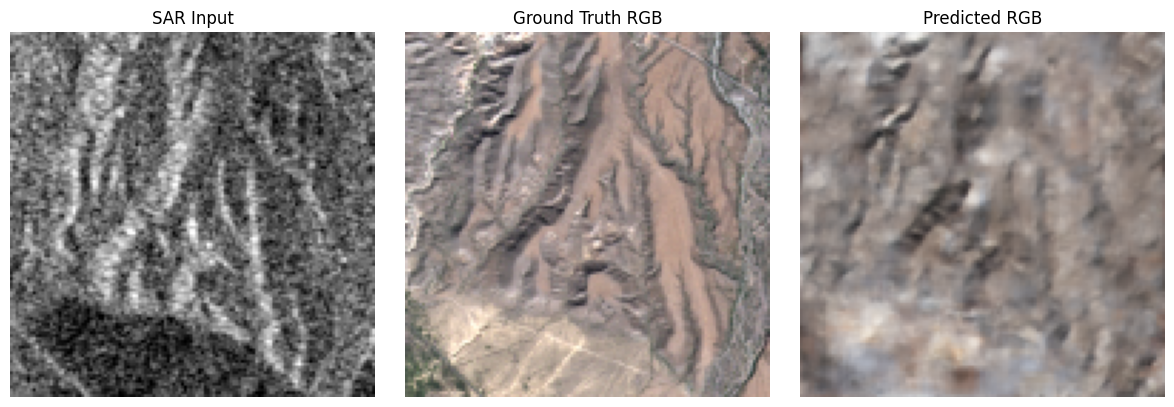

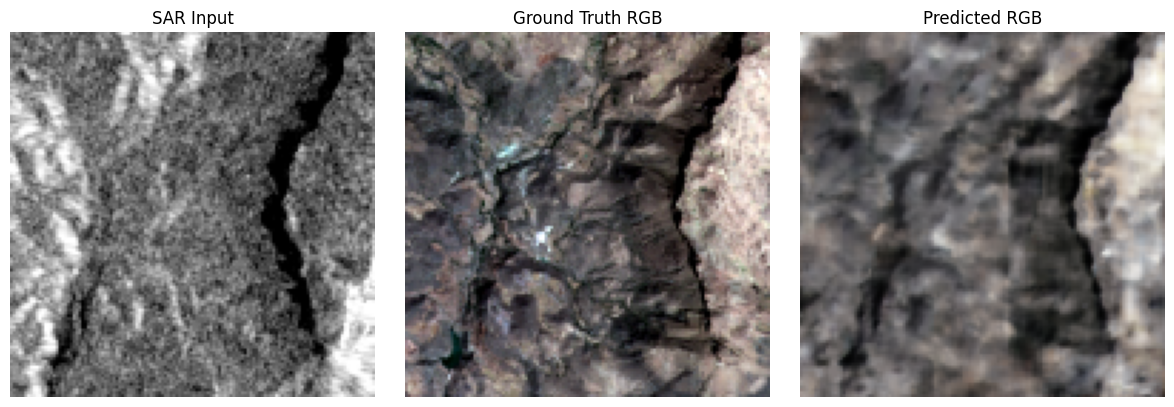

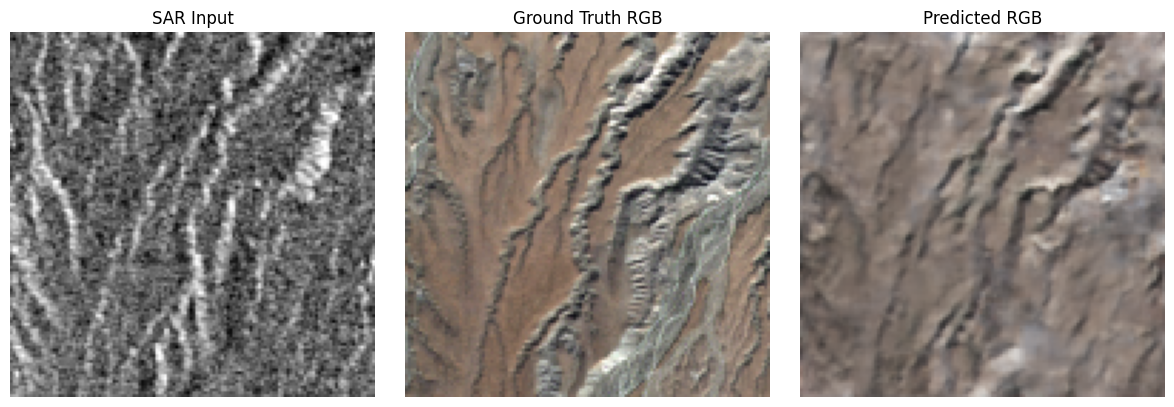

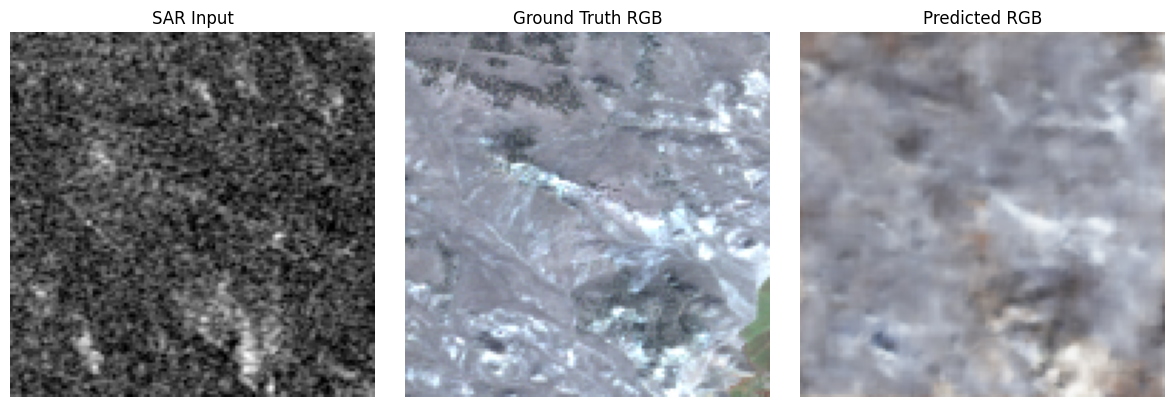

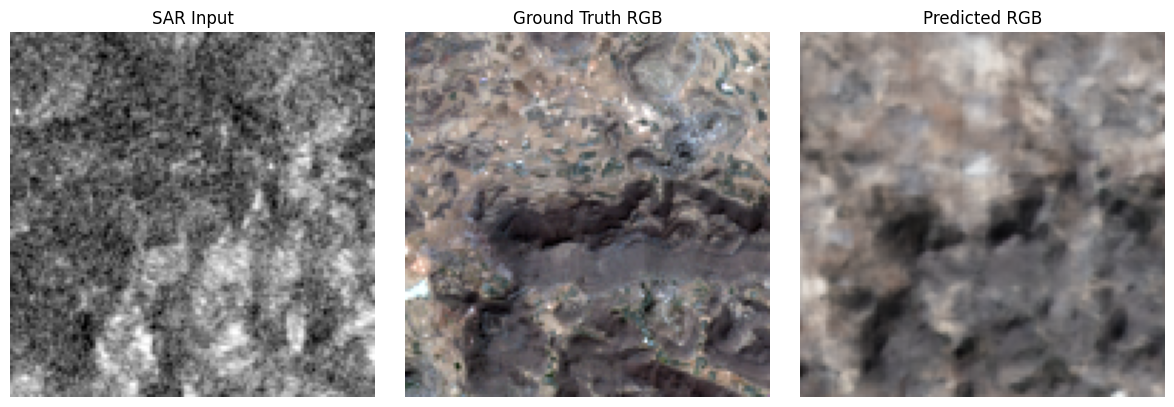

In [17]:
import matplotlib.pyplot as plt

# Get predictions
preds = unet.predict(X_val)

# Visualize N examples
N = 5
for i in range(N):
    sar_input = X_val[i].squeeze()          # (128, 128)
    true_rgb = Y_val[i]                     # (128, 128, 3)
    pred_rgb = preds[i]                     # (128, 128, 3)

    # Plot side by side
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("SAR Input")
    plt.imshow(sar_input, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth RGB")
    plt.imshow(true_rgb)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Predicted RGB")
    plt.imshow(pred_rgb)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [18]:
import cv2

save_dir = '/content/drive/MyDrive/barrenland_predictions'
os.makedirs(save_dir, exist_ok=True)

for i in range(len(preds)):
    pred_rgb_uint8 = (preds[i] * 255).astype('uint8')
    filename = f"pred_{i:04d}.png"
    cv2.imwrite(os.path.join(save_dir, filename), cv2.cvtColor(pred_rgb_uint8, cv2.COLOR_RGB2BGR))
